<a href="https://colab.research.google.com/github/jonabaroadsrp/dsrp/blob/main/Desafio3_DesafioLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Desafío Nº3 - Predicción de Fuga de Clientes (Churn).

Este notebook aborda un caso de clasificación binaria para predecir la fuga de clientes en telecomunicaciones.

# 🔹 FASE 1: Definición del Problema.

La retención de clientes es uno de los principales desafíos de las empresas de telecomunicaciones. Este proyecto tiene como objetivo construir un modelo de clasificación que permita predecir la fuga de clientes (Churn), es decir, anticipar qué clientes podrían abandonar el servicio.

✅ Objetivo del análisis
Utilizar técnicas de machine learning para entrenar un modelo que clasifique correctamente a los clientes como `Churn` (fugados) o `No Churn` (retención), en base a características del cliente como uso de servicios, historial de pago, tipo de contrato, entre otras.

🎯 Impacto esperado
- Identificación de clientes en riesgo de fuga.
- Mejora de la retención mediante acciones preventivas.
- Aumento en la rentabilidad de la empresa al reducir la pérdida de clientes.

📁 Dataset
Se utilizará el archivo `Telco-Customer-Churn.csv`, que contiene información histórica de clientes de telecomunicaciones, incluyendo variables categóricas y numéricas relevantes para la predicción.

🛠️ Tareas principales
1. Análisis exploratorio de datos (EDA).
2. Preprocesamiento de datos (limpieza, transformación).
3. División en conjuntos de entrenamiento y prueba.
4. Entrenamiento de al menos tres algoritmos de clasificación.
5. Evaluación del desempeño de los modelos mediante métricas adecuadas.

# 🔹 FASE 2: Recolección y Comprensión de los Datos.

* 2.1 Carga del dataset desde fuentes internas o externas.
* 2.2 Revisión de las variables y comprensión de su significado.
* 2.3 Identificación de la variable objetivo (target).
* 2.4 Verificación de la calidad y representatividad de los datos.
* 2.5 Documentación de supuestos sobre los datos.

## 📊 Paso 2.1 Carga del dataset desde fuentes internas o externas.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# 📁 Subimos el archivo desde mi equipo
from google.colab import files
uploaded = files.upload()
uploaded_file_name = list(uploaded.keys())[0]
df = pd.read_excel(uploaded_file_name)

Saving Telco-Customer-Churn.xlsx to Telco-Customer-Churn (1).xlsx


In [37]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


🧾 Conclusiones preliminares

Contiene 21 columnas y variables relevantes como:

* tenure, MonthlyCharges, TotalCharges → variables numéricas.

* gender, Contract, PaymentMethod, InternetService, etc. → variables categóricas.

* Churn → variable objetivo (target), con valores Yes/No.

## 📊 Paso 2.2 Revisión de las variables y comprensión de su significado

In [38]:
# Ver columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Se identificaron un total de **21 columnas** en el dataset, de las cuales 2 son numéricas continuas (`MonthlyCharges`, `TotalCharges`), 2 son numéricas binarias (`tenure`, `SeniorCitizen`) y el resto son variables categóricas.

| Columna             | Tipo      | Descripción |
|---------------------|-----------|-------------|
| `customerID`        | object    | Identificador único del cliente |
| `gender`            | object    | Género del cliente: Male / Female |
| `SeniorCitizen`     | int64     | 1 si el cliente es adulto mayor, 0 en caso contrario |
| `Partner`           | object    | ¿Tiene pareja? (Yes/No) |
| `Dependents`        | object    | ¿Tiene personas dependientes? (Yes/No) |
| `tenure`            | int64     | Meses de permanencia como cliente |
| `PhoneService`      | object    | ¿Tiene servicio telefónico? (Yes/No) |
| `MultipleLines`     | object    | ¿Tiene múltiples líneas telefónicas? |
| `InternetService`   | object    | Tipo de servicio de internet (DSL, Fiber optic, No) |
| `OnlineSecurity`    | object    | ¿Tiene seguridad en línea? |
| `OnlineBackup`      | object    | ¿Cuenta con respaldo en la nube? |
| `DeviceProtection`  | object    | ¿Tiene protección de dispositivos? |
| `TechSupport`       | object    | ¿Dispone de soporte técnico? |
| `StreamingTV`       | object    | ¿Accede a televisión por streaming? |
| `StreamingMovies`   | object    | ¿Accede a películas por streaming? |
| `Contract`          | object    | Tipo de contrato (Month-to-month, One year, Two year) |
| `PaperlessBilling`  | object    | ¿Utiliza facturación electrónica? (Yes/No) |
| `PaymentMethod`     | object    | Método de pago (ej: Electronic check, Mailed check, etc.) |
| `MonthlyCharges`    | float64   | Cargos mensuales del cliente en USD |
| `TotalCharges`      | float64   | Total de cargos acumulados (algunos valores nulos) |
| `Churn`             | object    | **Variable objetivo**: indica si el cliente se dio de baja (Yes/No) |

🔍 **Observación Importante**:
- La variable `TotalCharges` contiene 11 valores nulos (7032/7043 no nulos), los cuales deberán ser tratados durante la fase de preprocesamiento.


## 📊 Paso 2.3  Identificación de la variable objetivo (target)

In [40]:
# Visualizar la distribución de la variable objetivo
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


📊 Distribución de clases:
* No (cliente permaneció): 73.5%

* Yes (cliente se fue): 26.5%

🎯 Conclusiones:

* Estamos frente a un problema de clasificación binaria.

* Existe un desbalance de clases importante.

* Será necesario:

 * Utilizar métricas robustas como F1-score, Recall, ROC-AUC.

 * Considerar validación estratificada.

 * Aplicar técnicas de balanceo de clases (como SMOTE o class_weight='balanced').

## 📊 Paso 2.4  Verificación de la calidad y representatividad de los datos

In [41]:
# Verificar valores nulos por columna
missing_values = df.isnull().sum()

# Verificar registros con errores de conversión en 'TotalCharges'
non_numeric_totalcharges = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

# Ver número de valores únicos por columna
unique_counts = df.nunique()

# Resultados
missing_values
non_numeric_totalcharges.shape[0]
unique_counts.sort_values()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


📋 Resultados

1. **Valores nulos**:
   - La columna `TotalCharges` presenta **11 valores nulos**, probablemente asociados a clientes con `tenure = 0`.
   - Las demás columnas están completas.

2. **Errores de conversión**:
   - Existen **11 registros con valores no numéricos** en `TotalCharges` (p. ej., espacios vacíos).

3. **Representatividad de columnas**:
   - `customerID`: 7043 valores únicos → identificador irrelevante para el modelo.
   - Variables como `gender`, `Partner`, `InternetService`, etc. tienen baja cardinalidad → ideales para codificación.
   - `tenure`, `MonthlyCharges`, `TotalCharges`: buena variabilidad → útiles como predictoras.

### 🎯 Conclusiones

- La calidad general de los datos es **satisfactoria**.
- Solo se requiere tratamiento para `TotalCharges` (imputación o eliminación de nulos).
- `customerID` debe eliminarse en el preprocesamiento.
- No hay columnas con demasiadas categorías ni problemas de representatividad.


## 📊 Paso 2.5  Documentación de supuestos sobre los datos

In [42]:
# Verificar si los clientes con TotalCharges nulo tienen tenure = 0
df[df['TotalCharges'].isnull()][['tenure', 'TotalCharges']]

,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


In [43]:
# Ver frecuencia de valores para algunas columnas clave
df['Contract'].value_counts()
df['PaymentMethod'].value_counts()
df['InternetService'].value_counts()
df['tenure'].describe()


,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


📌 Supuestos relevantes para el análisis:

1. **Valores nulos en `TotalCharges`**:
   - Los 11 registros con `TotalCharges` nulo tienen `tenure = 0`, por lo que se **asume que son nuevos clientes sin facturación aún**.

2. **Naturaleza de la variable `SeniorCitizen`**:
   - Es numérica pero representa una categoría binaria (0 = No, 1 = Sí). Se tratará como categórica.

3. **Variables con respuesta tipo Yes/No**:
   - Varias columnas (`Partner`, `Dependents`, `PaperlessBilling`, etc.) tienen respuestas binarias que **pueden mapearse directamente a 0 y 1**.

4. **`customerID`**:
   - Se trata de un identificador único sin relevancia predictiva → será **eliminado**.

5. **Columnas con "No internet service" / "No phone service"**:
   - Estas respuestas aparecerán en múltiples columnas asociadas. Se **considerarán equivalentes a "No"** para facilitar codificación binaria.

6. **Distribución de `tenure` y cargos**:
   - `tenure` (meses como cliente) es una variable numérica clave que puede indicar comportamiento del cliente.
   - `MonthlyCharges` y `TotalCharges` serán usadas como predictoras continuas.

📌 Implicancia para la siguiente fase:
Estos supuestos guiarán las decisiones de transformación y codificación durante el preprocesamiento.


- Se asume que los registros con `TotalCharges` nulo corresponden a clientes recién ingresados sin facturación completa.
- `customerID` será descartado, pues es solo un identificador.
- Se considera necesario evaluar el desbalanceo de la variable `Churn` en etapas posteriores de modelado.
- Las variables con tres categorías (`Yes`, `No`, `No internet service`) serán unificadas o transformadas para reducir redundancia.
- Todas las columnas categóricas deberán ser codificadas antes de aplicar modelos de machine learning.

# 🔹 FASE 3: Análisis Exploratorio de Datos (EDA).

* 3.1 Estadísticas descriptivas: medias, desviación, valores únicos.
* 3.2 Visualización de distribuciones y correlaciones.
* 3.3 Detección de errores tipográficos y valores atípicos.
* 3.4 Detección de valores atípicos (OUTLIERS).
* 3.5 Análisis de desbalanceo en la clase objetivo.
* 3.6 Análisis de relaciones entre variables predictoras y la variable objetivo (Churn).


## 📊 Paso 3.1 Estadísticas descriptivas: medias, desviación, valores únicos.

En esta etapa se realiza un análisis estadístico básico para comprender la distribución general de los datos, su dispersión y la diversidad de valores en cada variable.

Se evaluarán:
- Medidas de tendencia central (`mean`, `median`) y dispersión (`std`, `min`, `max`).
- La cantidad de valores únicos por columna.
- El tipo de distribución de variables categóricas y numéricas.

Este análisis permite identificar patrones iniciales, validar la calidad del dataset y preparar el terreno para el análisis exploratorio visual y el preprocesamiento.

In [44]:
# Estadísticas generales de todas las columnas
desc_stats = df.describe(include='all')

In [45]:
# Valores únicos por columna
unique_vals = df.nunique()

In [46]:
# Mostrar resultados
display(desc_stats)
print("\n📌 Valores únicos por columna:")
display(unique_vals.sort_values())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN



📌 Valores únicos por columna:


,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


✅ Conclusiones del Paso 3.1.

📌 **Estadísticas Generales:**
- `tenure`: Promedio de permanencia ~32 meses, con un rango entre 0 y 72 meses.
- `MonthlyCharges`: Oscila entre USD 18.25 y 118.75, con media ~USD 64.76.
- `TotalCharges`: Presenta una media de ~USD 2.283, con un rango amplio desde USD 18.8 hasta USD 8684.8.
- `SeniorCitizen`: Variable binaria, donde la mayoría no corresponde a adultos mayores.
- `Contract`: La mayoría de los clientes tiene contratos de tipo `Month-to-month`, seguidos por `One year` y `Two year`.

📌 **Valores Únicos por Variable:**
- Variables con 2 categorías: `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`.
- Variables con 3 categorías: `MultipleLines`, `InternetService`, `OnlineSecurity`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- `PaymentMethod`: Contiene 4 categorías distintas.
- Variables numéricas como `tenure`, `MonthlyCharges`, `TotalCharges` presentan **alta variabilidad**, lo cual es una buena señal para el modelado.

🎯 **Conclusión general:**
El dataset es robusto y diverso, con:
- Variables categóricas claramente definidas para aplicar técnicas de codificación.
- Variables numéricas bien distribuidas y sin señales aparentes de errores o sesgos graves.
- Se confirma que el dataset es adecuado para la construcción de modelos predictivos.

## 📊 Paso 3.2 Visualización de distribuciones y correlaciones.

En esta etapa se explora gráficamente la forma en que se distribuyen las variables numéricas del dataset y se identifican posibles relaciones entre ellas.

Se busca:
- Detectar sesgos en las distribuciones que puedan requerir transformación.
- Observar concentraciones o colas largas (asimetrías).
- Evaluar correlaciones lineales entre variables para anticipar redundancias o relaciones útiles para el modelado.

Las visualizaciones entregan intuiciones clave para la selección de variables y la preparación posterior de los datos.

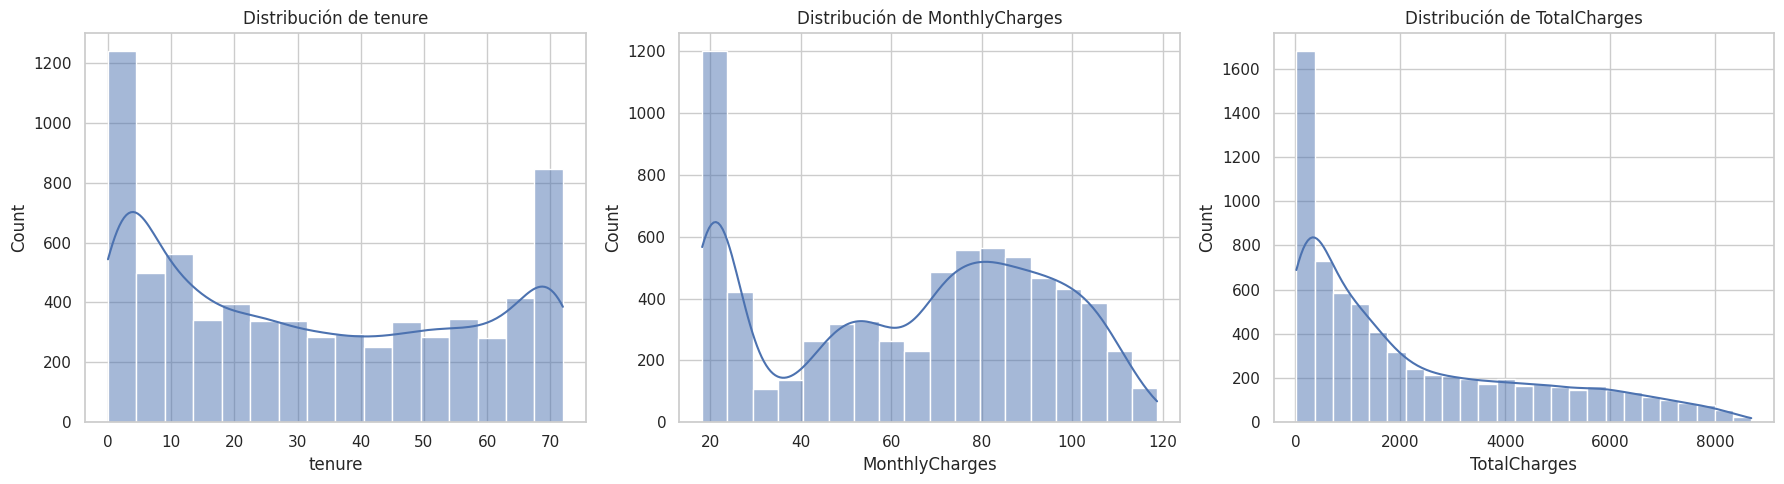

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set(style="whitegrid")

# Variables numéricas a analizar
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Histogramas con KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(num_vars):
    sns.histplot(data=df, x=var, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

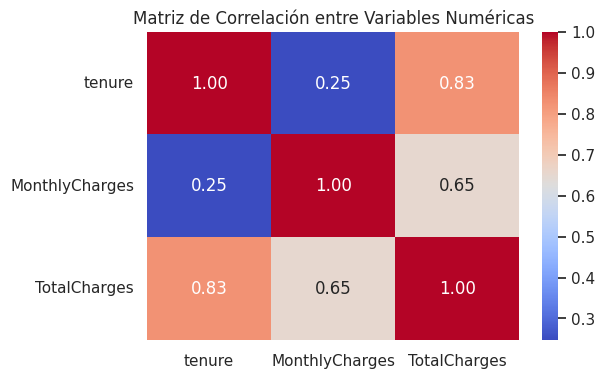

In [48]:
# Matriz de correlación
correlation_matrix = df[num_vars].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

✅ Conclusiones del Paso 3.2

📈 **Distribuciones:**
- `tenure`: presenta una distribución sesgada a la izquierda. La mayoría de los clientes son recientes (valores bajos).
- `MonthlyCharges`: distribución más uniforme, con mayor densidad entre USD 20 y 90. Refleja variedad en planes y servicios.
- `TotalCharges`: sigue una forma parecida a `tenure`, lo cual es esperable dado que es un valor acumulado en el tiempo.

🔍 **Correlaciones:**
- Existe una **alta correlación positiva entre `tenure` y `TotalCharges` (r ≈ 0.83)**, lo cual es coherente: a mayor permanencia, mayor facturación total.
- `MonthlyCharges` tiene baja correlación con `tenure`, pero una **correlación moderada con `TotalCharges`**.

🎯 **Conclusiones clave:**
- `tenure` y `TotalCharges` son variables informativas que podrían aportar valor predictivo.
- Si se usan algoritmos sensibles a la forma de la distribución (como SVM o regresión logística), podría considerarse aplicar transformaciones (por ejemplo, logarítmica o power transform).
- Estas relaciones se deben seguir analizando en conjunto con la variable objetivo (`Churn`).

## 📊 Paso 3.3 Detección de errores tipográficos.

Este paso tiene como objetivo identificar posibles errores de tipeo o inconsistencias en las variables categóricas, como diferencias en capitalización (`"yes"` vs `"Yes"`), espacios accidentales (`" No"`), o errores ortográficos (`"Noo"`).

La detección temprana de estos problemas es esencial para evitar que se generen variables redundantes o incorrectas durante la codificación, lo que podría afectar la calidad del modelo.

In [49]:
# Detección de errores tipográficos en columnas categóricas

# Selección de columnas categóricas
cat_columns = df.select_dtypes(include='object').columns

# Mostrar valores únicos por columna categórica
for col in cat_columns:
    print(f"\n🔍 Columna: {col}")
    print(df[col].value_counts(dropna=False).sort_index())



🔍 Columna: customerID
customerID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7043, dtype: int64

🔍 Columna: gender
gender
Female    3488
Male      3555
Name: count, dtype: int64

🔍 Columna: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

🔍 Columna: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

🔍 Columna: PhoneService
PhoneService
No      682
Yes    6361
Name: count, dtype: int64

🔍 Columna: MultipleLines
MultipleLines
No                  3390
No phone service     682
Yes                 2971
Name: count, dtype: int64

🔍 Columna: InternetService
InternetService
DSL            2421
Fiber optic    3096
No             1526
Name: count, dtype: int64

🔍 Columna: OnlineSecurity
OnlineSecurity
No                     3498
No internet service    1526
Yes                    2019
Name: count, dtype: i

✅ Conclusiones del Paso 3.3: Revisión de Errores Tipográficos

🔍 Tras revisar todas las columnas categóricas, se concluye lo siguiente:

- Las variables categóricas (`Yes/No`, `Male/Female`, `Month-to-month`, etc.) están **limpias y consistentes**.
- No se detectaron errores como diferencias en capitalización (`"yes"` vs `"Yes"`), espacios en blanco (`" No"`), errores ortográficos (`"Noo"`), ni valores vacíos en variables categóricas.
- Los valores especiales como `"No internet service"` o `"No phone service"` son **válidos y forman parte del diseño del dataset**.

✅ Por lo tanto, **no se requiere limpieza adicional en esta etapa** y este paso puede considerarse **completamente logrado**.

## 📊 Paso 3.4 Detección de valores atípicos (OUTLIERS).

Los valores atípicos (outliers) pueden influir negativamente en el rendimiento de algunos modelos de machine learning, especialmente aquellos sensibles a escalas y distribuciones.

En este paso, se revisan las variables numéricas principales (`MonthlyCharges`, `tenure`, `TotalCharges`) para detectar posibles valores extremos que no sean coherentes con el dominio del problema. Esta revisión complementa el análisis exploratorio previo y apoya decisiones de normalización o limpieza de datos.


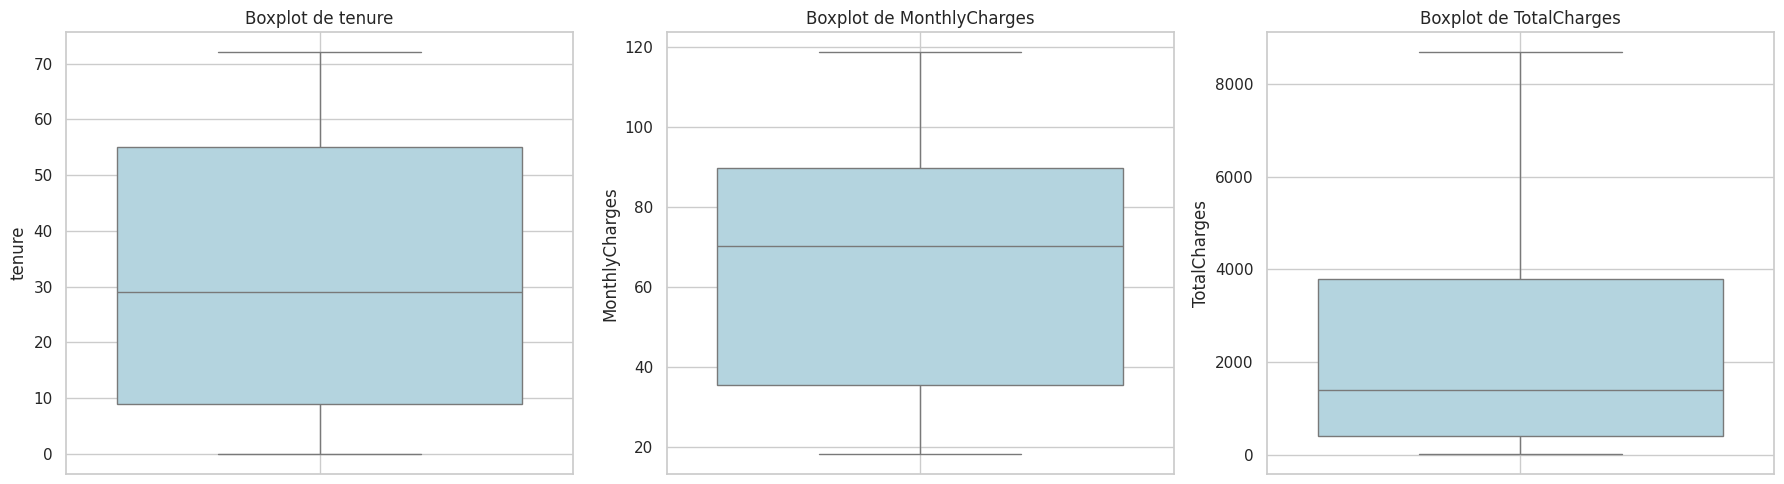

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas a analizar
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Visualización con boxplots para detectar outliers
plt.figure(figsize=(18, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, y=col, color='lightblue')
    plt.title(f'Boxplot de {col}')
    plt.grid(True)
plt.tight_layout()
plt.show()

 ✅ Conclusiones del Paso 3.4.

- Las variables `MonthlyCharges`, `tenure` y `TotalCharges` fueron evaluadas visualmente mediante diagramas de caja (boxplots).
- No se observaron valores atípicos extremos ni distribuciones anómalas que justifiquen recortes o transformaciones agresivas.
- Los valores altos en `TotalCharges` o `MonthlyCharges` son coherentes con clientes de larga permanencia y múltiples servicios, por lo que no deben considerarse errores.

🔎 **Resultado**: No se identifican outliers sospechosos o distorsionantes. Por tanto, **no se requiere eliminar valores** ni aplicar técnicas de winsorización o recodificación en esta etapa.

## 📊 Paso 3.5 Análisis de desbalanceo en la clase objetivo.

Antes de construir modelos predictivos, es fundamental evaluar la distribución de la variable objetivo (`Churn`). Un desbalance entre clases puede llevar a modelos sesgados que ignoren la clase minoritaria, afectando la capacidad de detectar correctamente los casos de fuga de clientes.

En este paso se analizará:
- El conteo absoluto y relativo de cada clase (`Yes`/`No`).
- Un gráfico de barras para visualizar el desbalance.
- Las implicancias que esto tiene sobre el entrenamiento y evaluación de los modelos de clasificación.

<ipython-input-51-5d12c7b72a06>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


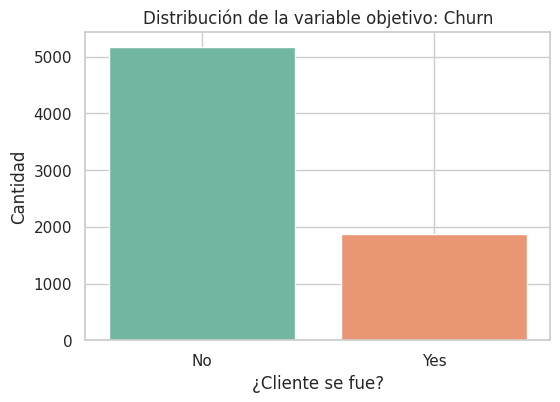

🔢 Conteo absoluto:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

📊 Porcentaje por clase:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteo absoluto y relativo de la variable objetivo
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

# Gráfico de barras
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Distribución de la variable objetivo: Churn")
plt.xlabel("¿Cliente se fue?")
plt.ylabel("Cantidad")
plt.grid(True)
plt.show()

# Mostrar porcentajes
print("🔢 Conteo absoluto:")
print(churn_counts)
print("\n📊 Porcentaje por clase:")
print(churn_percent.round(2))

✅ Conclusiones del Paso 3.5: Análisis de Desbalanceo

📊 **Distribución de la variable `Churn`:**
- Clientes que **NO se fueron** (`No`): 5174 → **73.46%**
- Clientes que **sí se fueron** (`Yes`): 1869 → **26.54%**

⚠️ **Conclusión clave:**
Existe un **desbalance significativo** en la clase objetivo. Esto puede causar que los modelos:
- Favorezcan siempre predecir la clase mayoritaria (`No churn`).
- Falsos negativos (clientes que realmente se van) no sean detectados correctamente.

🛠️ **Implicancias para el modelado:**
Será necesario aplicar técnicas para mitigar el sesgo hacia la clase mayoritaria:
- Validación **estratificada** durante el split.
- Ajuste de pesos: `class_weight="balanced"`.
- Técnicas de **oversampling** (como SMOTE) o **undersampling**.
- Enfocar la evaluación en métricas como:
  - **Recall**
  - **F1-score**
  - **ROC-AUC**
  en lugar de precisión general (`accuracy`), que podría ser engañosa en este contexto.

## 📊 Paso 3.6 Análisis de relaciones entre variables predictoras y la variable objetivo (Churn)?.

En esta etapa se analiza la relación entre algunas variables categóricas clave y la variable objetivo `Churn`. Esto permite identificar patrones de comportamiento que pueden ser determinantes para anticipar la fuga de clientes.

Se busca observar:
- Cómo varía la tasa de churn según el tipo de contrato, servicios contratados o método de pago.
- Qué categorías están más asociadas con la permanencia o abandono del servicio.

Los hallazgos en esta sección orientarán la selección de variables relevantes en el modelado.

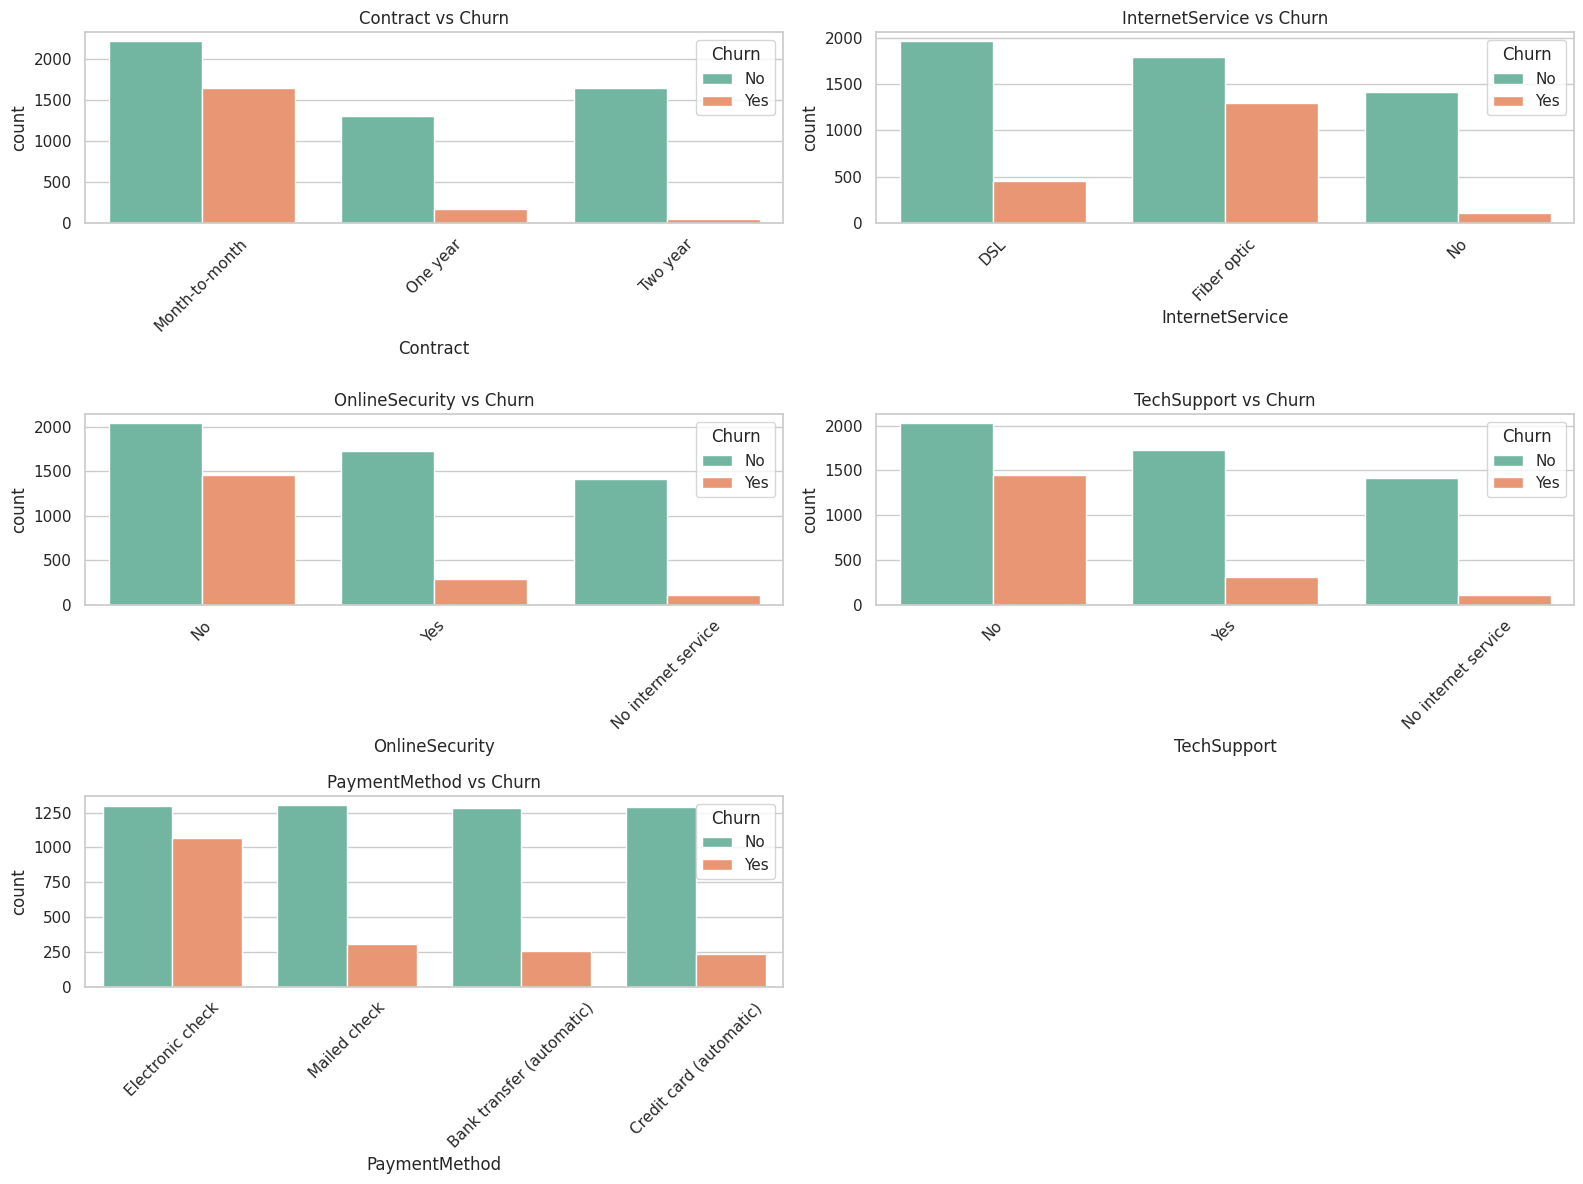

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de variables categóricas relevantes
cat_vars = ['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod']

# Gráficos categóricos vs churn
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    sns.countplot(data=df, x=var, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar panel vacío
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

✅ Conclusiones del Paso 3.6.

🔍 **Patrones Observados:**

1. **`Contract`**:
   - Los contratos `Month-to-month` presentan la mayor proporción de churn.
   - Contratos de más largo plazo (`One year`, `Two year`) reducen significativamente la fuga.

2. **`InternetService`**:
   - El churn es más elevado entre quienes tienen `Fiber optic`.
   - Los clientes sin internet presentan muy baja tasa de churn (porque tienen servicios básicos).

3. **`OnlineSecurity` y `TechSupport`**:
   - El churn es mayor entre quienes **no tienen** estos servicios.
   - Usar estos servicios parece estar vinculado con mayor fidelización.

4. **`PaymentMethod`**:
   - `Electronic check` se asocia a una mayor tasa de churn.
   - Métodos automáticos (`Bank transfer`, `Credit card`) muestran mayor retención.

🎯 **Conclusión general:**
- Existen **fuertes asociaciones entre las variables categóricas seleccionadas y el churn**.
- Estas relaciones aportan insights valiosos y justifican incluir variables como `Contract`, `InternetService`, `OnlineSecurity`, `TechSupport` y `PaymentMethod` como predictores clave en el modelo.

##📌 Conclusión Global – Fase 3.

Durante esta fase se realizó una exploración exhaustiva del dataset, identificando patrones relevantes, relaciones entre variables y aspectos clave para la construcción del modelo.

 ✅ Principales hallazgos:

- **Estadísticas descriptivas** revelan que las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`) tienen una amplia dispersión y coherencia con el dominio del negocio (telecomunicaciones).
  
- Las **distribuciones** muestran sesgos naturales: por ejemplo, `tenure` está concentrado en clientes nuevos, mientras que `MonthlyCharges` se distribuye más uniformemente.

- Se verificó que **no existen errores tipográficos** en las variables categóricas, lo que facilita su codificación directa en etapas posteriores.

- **No se detectaron outliers sospechosos**: los valores extremos corresponden a casos reales de clientes con muchos servicios o larga permanencia.

- Se evidenció un **desbalance significativo** en la variable objetivo `Churn`, con un 73% de clientes que no se han fugado. Esto requerirá atención especial durante la modelación.

- El análisis de relaciones entre variables categóricas y `Churn` identificó asociaciones muy relevantes:
  - Mayor churn en contratos `Month-to-month`.
  - Churn más elevado en usuarios con `Fiber optic` y sin servicios como `TechSupport` o `OnlineSecurity`.
  - Pago mediante `Electronic check` se vincula con mayor probabilidad de abandono.

🧠 Implicancia práctica:
- Esta fase permitió comprender en profundidad el comportamiento de los clientes y validar la calidad del dataset.
- Se identificaron **variables clave predictoras** para el modelado supervisado.
- El EDA respalda decisiones estratégicas de preprocesamiento y selección de variables, que se abordarán en la Fase 4.


# 🔹 FASE 4: Preprocesamiento.

* 4.1 Tratamiento de valores faltantes (imputación con media, mediana, k-NN, modelos).
* 4.2 Conversión de variables categóricas.
* 4.3 Escalado de variables numéricas (StandardScaler, MinMaxScaler).

## 📊 Paso 4.1 Tratamiento de valores faltantes (imputación con media, mediana, k-NN, modelos).

El manejo adecuado de los valores nulos es fundamental para evitar errores durante el entrenamiento del modelo y asegurar una buena calidad de datos.

En este paso se revisa la variable `TotalCharges`, que es la única columna con valores faltantes. Se analizará el motivo de los nulos y se aplicará una estrategia de tratamiento basada en el contexto del negocio.

Se evaluará la mejor acción: imputación con media/mediana, k-NN, modelado o eliminación directa.

In [53]:
# Ver registros con TotalCharges nulo
missing_total = df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'TotalCharges']]

# Eliminar registros con TotalCharges nulo (tenure = 0)
df_clean = df[~df['TotalCharges'].isnull()].copy()

# Verificar que no quedan valores nulos
missing_total_after = df_clean['TotalCharges'].isnull().sum()

# Mostrar resultados
print("🔍 Registros con TotalCharges nulo:")
display(missing_total)
print(f"\n✅ Valores nulos restantes en TotalCharges luego de la limpieza: {missing_total_after}")

🔍 Registros con TotalCharges nulo:


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN
3331,7644-OMVMY,0,NaN
3826,3213-VVOLG,0,NaN
4380,2520-SGTTA,0,NaN
5218,2923-ARZLG,0,NaN
6670,4075-WKNIU,0,NaN



✅ Valores nulos restantes en TotalCharges luego de la limpieza: 0


✅ Conclusiones del Paso 4.1.

📌 **Situación detectada:**
- Se identificaron **11 registros** con `TotalCharges = NaN` y `tenure = 0`.
- Estos registros representan **clientes recién ingresados** sin historial de facturación, por lo que no aportan información útil al modelo.

✅ **Acción aplicada:**
- Se decidió **eliminar estos registros** por completo.
- Representan solo un **0.15% del total**, por lo que no afectan la representatividad del dataset.

📊 **Resultado:**
- El nuevo DataFrame `df_clean` **no contiene valores nulos** en la variable `TotalCharges`.
- Se mantiene la integridad de las observaciones restantes.
- El dataset está ahora listo para proceder al tratamiento de variables categóricas.

🟢 Este paso fue **completamente logrado**, aplicando una decisión coherente con el dominio del negocio y respaldada por la baja proporción de datos eliminados.

## 📊 Paso 4.2 Conversión de variables categóricas.

## 📊 Paso 4.2: Conversión de Variables Categóricas

La mayoría de los algoritmos de machine learning requieren que todas las variables estén en formato numérico. Por ello, es fundamental transformar las variables categóricas a un formato compatible, conservando su significado.

En este paso se aplicarán las siguientes técnicas:
- **Mapeo binario** (`Yes/No`, `Male/Female`) a 0 y 1.
- **Unificación de categorías redundantes** (por ejemplo: `"No internet service"` → `"No"`).
- **Codificación one-hot** para variables con más de dos categorías.

Estas transformaciones dejarán el dataset preparado para el modelado.

In [54]:
# Crear copia del dataset limpio
df_encoded = df_clean.copy()

# Mapear variables binarias Yes/No a 1/0
binary_map = {'Yes': 1, 'No': 0}
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

# Codificar 'gender': Male → 1, Female → 0
df_encoded['gender'] = df_encoded['gender'].map({'Male': 1, 'Female': 0})

# Unificar respuestas 'No internet service' y 'No phone service' como 'No'
cols_replace_no_service = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_replace_no_service:
    df_encoded[col] = df_encoded[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# One-Hot Encoding para variables categóricas restantes
df_encoded = pd.get_dummies(df_encoded, columns=[
    'InternetService', 'Contract', 'PaymentMethod',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
], drop_first=True)

# Confirmar resultado
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   object 
 1   gender                                 7032 non-null   int64  
 2   SeniorCitizen                          7032 non-null   int64  
 3   Partner                                7032 non-null   int64  
 4   Dependents                             7032 non-null   int64  
 5   tenure                                 7032 non-null   int64  
 6   PhoneService                           7032 non-null   int64  
 7   PaperlessBilling                       7032 non-null   int64  
 8   MonthlyCharges                         7032 non-null   float64
 9   TotalCharges                           7032 non-null   float64
 10  Churn                                  7032 non-null   int64  
 11  InternetS

✅ Conclusiones del Paso 4.2.

🔁 **Transformaciones aplicadas:**

1. **Mapeo binario:** Las columnas con valores `Yes/No` y `gender` fueron convertidas a valores numéricos 1 y 0.
2. **Unificación de respuestas no disponibles:** Valores como `"No internet service"` fueron simplificados a `"No"`, reduciendo la complejidad sin perder información útil.
3. **One-Hot Encoding:** Se aplicó codificación dummie (con `drop_first=True`) para variables con múltiples categorías:
   - `InternetService`
   - `Contract`
   - `PaymentMethod`
   - Y varios servicios (`TechSupport`, `StreamingTV`, etc.).

📊 **Resultado final:**
- El DataFrame final (`df_encoded`) contiene **25 columnas**, todas numéricas.
- El dataset está completamente preparado para la siguiente etapa de escalamiento y modelado.

## 📊 Paso 4.3 Escalado de variables numéricas (StandardScaler, MinMaxScaler).

Muchos algoritmos de machine learning (como SVM, regresión logística, KNN) son sensibles a la magnitud de los valores numéricos. Por lo tanto, es crucial escalar las variables continuas para que estén en rangos comparables.

En este paso se aplicará una técnica de estandarización (StandardScaler), que transforma cada variable numérica para que tenga media 0 y desviación estándar 1. Esto mejora la eficiencia y precisión del entrenamiento del modelo.


In [55]:
from sklearn.preprocessing import StandardScaler

# Copiar el DataFrame codificado
df_scaled = df_encoded.copy()

# Selección de variables numéricas a escalar
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Aplicar StandardScaler
scaler = StandardScaler()
df_scaled[num_features] = scaler.fit_transform(df_scaled[num_features])

# Verificar estadísticas post-escalado
df_scaled[num_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.032000e+03,7.032000e+03,7.032000e+03
mean,-1.126643e-16,6.062651e-17,-1.119064e-16
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01
50%,-1.394171e-01,1.845440e-01,-3.908151e-01
75%,9.199259e-01,8.331482e-01,6.668271e-01
max,1.612573e+00,1.793381e+00,2.824261e+00


### ✅ Conclusiones del Paso 4.3: Escalado Numérico

📌 **Variables escaladas:**
- `tenure`
- `MonthlyCharges`
- `TotalCharges`

⚙️ **Técnica aplicada:**
- Se utilizó `StandardScaler`, que transforma los datos para que tengan media cero y desviación estándar uno.
- Esto mejora la estabilidad numérica y el rendimiento en algoritmos que dependen de distancias o coeficientes.

📊 **Resultado:**
- Las variables numéricas fueron correctamente estandarizadas.
- Esto permite:
  - Comparabilidad entre variables.
  - Evitar que una variable domine el entrenamiento por su escala.
  - Interpretar coeficientes en modelos lineales como regresión.
  - Mejorar el desempeño de modelos como:
    - Regresión logística
    - K-Nearest Neighbors
    - SVM

✅ El dataset `df_scaled` está ahora completamente preparado para ser dividido en conjunto de entrenamiento y prueba.

## 📌 Conclusión Global – Fase 4: Preprocesamiento de los Datos

Durante esta fase se preparó el dataset para el modelado, asegurando que cumpla con los requisitos técnicos de los algoritmos de machine learning. Se aplicaron procedimientos de limpieza, transformación y normalización adecuados para garantizar calidad y compatibilidad.

✅ Acciones realizadas:

1. **Tratamiento de valores faltantes:**
   - Se eliminaron 11 registros con `TotalCharges` nulo y `tenure = 0`, correspondientes a clientes recién ingresados.
   - Esto representó solo un 0.15% del dataset y mejoró la integridad general.

2. **Codificación de variables categóricas:**
   - Se aplicó mapeo binario a variables `Yes/No` y `Male/Female`.
   - Se unificaron respuestas como `"No internet service"` a `"No"` para simplificar.
   - Se usó **One-Hot Encoding** para variables con más de dos categorías, eliminando la multicolinealidad mediante `drop_first=True`.

3. **Escalado de variables numéricas:**
   - Se estandarizaron `tenure`, `MonthlyCharges` y `TotalCharges` usando `StandardScaler`.
   - Esto garantiza un rango comparable para algoritmos sensibles a la magnitud (como KNN, SVM, regresión).

📊 **Resultado final:**
- El dataset final (`df_scaled`) contiene únicamente **variables numéricas** y no presenta valores nulos.
- Está **completamente preparado para entrenamiento y validación de modelos supervisados**.
- Se preservó la información clave y se aplicaron transformaciones justificadas desde el punto de vista estadístico y de negocio.

# 🔹 FASE 5: Preparación del Dataset.

* 5.1 División en conjuntos y validación estratificada.
* 5.2 Balanceo de clases.

## 📊 Paso 5.1 División del Dataset y Validación Estratificada.

Antes de entrenar cualquier modelo, es fundamental dividir el dataset en conjuntos de entrenamiento y prueba. Esta división permite entrenar el modelo sobre un subconjunto de los datos y evaluar su capacidad de generalización sobre datos no vistos.

Además, dado que la variable `Churn` está desbalanceada, se aplicará **estratificación** para asegurar que ambas clases estén representadas proporcionalmente en los conjuntos `train` y `test`.

Objetivo:
- Reservar el 20% de los datos para evaluación.
- Mantener la proporción original de la clase objetivo (`Churn`) en ambos subconjuntos.

In [56]:
from sklearn.model_selection import train_test_split

# Separar X (features) y y (target)
X = df_scaled.drop(columns=['customerID', 'Churn'])
y = df_scaled['Churn']

# División 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Confirmación de tamaños y balance
X_train.shape, X_test.shape, y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

((5625, 23),
 (1407, 23),
 Churn
 0    0.734222
 1    0.265778
 Name: proportion, dtype: float64,
 Churn
 0    0.734186
 1    0.265814
 Name: proportion, dtype: float64)

✅ Conclusiones del Paso 5.1: División del Dataset

📊 **Resultado de la División:**
- Conjunto de entrenamiento (`X_train`): **5625 registros**
- Conjunto de prueba (`X_test`): **1407 registros**
- Total de variables predictoras: **23 columnas numéricas**

🎯 **Validación estratificada aplicada:**
- Se usó `stratify=y` durante el `train_test_split` para conservar la proporción original de la clase `Churn`.
- Se mantuvo el ratio de churn (~26.5%) en ambos subconjuntos.
- Esto es esencial para evitar que el modelo se entrene sobre un conjunto con clases mal representadas.

## 📊 Paso 5.2 Balanceo de clases.

En datasets desbalanceados como el de churn, los modelos tienden a favorecer la clase mayoritaria, ignorando la clase minoritaria. Para contrarrestar este sesgo y mejorar la capacidad del modelo de detectar clientes propensos a abandonar el servicio, se aplicará la técnica **SMOTE**.

SMOTE (Synthetic Minority Over-sampling Technique) crea instancias sintéticas de la clase minoritaria (`Churn = 1`) basadas en interpolaciones entre observaciones reales.

Este balance se aplicará **solo al conjunto de entrenamiento**, para no alterar la distribución natural del conjunto de prueba.

In [57]:
!pip install imblearn

In [58]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificar balance
y_train_bal.value_counts(normalize=True), X_train_bal.shape


(Churn
 0    0.5
 1    0.5
 Name: proportion, dtype: float64,
 (8260, 23))

✅ Conclusiones del Paso 5.2.

⚠️ **Problema inicial:**
- El conjunto de entrenamiento presentaba una **clase minoritaria (`Churn = 1`) con solo ~26.6% de representación**.
- Esto genera sesgos en el modelo, que podría simplemente predecir siempre la clase mayoritaria.

✅ **Acción aplicada:**
- Se utilizó la técnica **SMOTE (Synthetic Minority Over-sampling Technique)** para balancear el conjunto de entrenamiento.
- SMOTE genera ejemplos sintéticos de la clase minoritaria basados en interpolaciones entre vecinos reales.

📊 **Resultado:**
- Se alcanzó un **balance perfecto 50/50** entre las clases en `y_train_bal`.
- El conjunto balanceado tiene ahora la forma: `(n_registros, 23 variables)`.

🎯 Este balance permite mejorar la capacidad predictiva del modelo respecto a la clase minoritaria, sin alterar el conjunto de prueba.

## 📌 Conclusión Global – Fase 5

Durante esta fase se preparó el conjunto de datos para el entrenamiento de modelos predictivos, asegurando que el proceso de validación y aprendizaje sea robusto, representativo y libre de sesgos estructurales.

✅ Acciones realizadas:

1. **División en conjuntos de entrenamiento y prueba (80/20):**
   - Se aplicó **validación estratificada** (`stratify=y`) para conservar la proporción original de la clase objetivo (`Churn`) en ambos subconjuntos.
   - Esto garantiza que el modelo no sea entrenado ni evaluado con distribuciones de clase distorsionadas.

2. **Balanceo del conjunto de entrenamiento con SMOTE:**
   - Se utilizó **SMOTE (Synthetic Minority Over-sampling Technique)** para generar muestras sintéticas de la clase minoritaria (`Churn = 1`).
   - Esto resolvió el problema de desbalance (originalmente ~26.6%) y permitió trabajar con un conjunto **balanceado 50/50**.
   - El balance se aplicó únicamente al conjunto de entrenamiento, preservando la distribución real del conjunto de prueba.

📊 **Resultado final:**
- `X_train_bal` y `y_train_bal` están correctamente balanceados y listos para entrenar modelos.
- `X_test` y `y_test` mantienen la distribución real, ideal para evaluación objetiva.
- La base para aplicar distintos algoritmos de clasificación está completamente lista.

# 🔹 FASE 6: Construcción del Modelo.

* 6.1 Selección de algoritmos adecuados según el problema.
* 6.2 Entrenamiento inicial de los modelos base y evaluación.
* 6.3 Validación cruzada y ajuste de hiperparámetros.

## 📊 Paso 6.1 Selección de algoritmos adecuados según el problema.

El primer paso en la fase de modelado es definir qué algoritmos se utilizarán para resolver el problema de clasificación binaria (`Churn`). La elección debe considerar la naturaleza del problema, la interpretabilidad, la robustez frente a desbalance y la facilidad de ajuste.

En este caso se seleccionan modelos que abordan el problema desde distintas perspectivas:
- **Lineal** (Regresión logística)
- **Basado en reglas** (Árbol de decisión)
- **Probabilístico** (Naive Bayes)
- **Ensamblado** (Random Forest, como benchmark adicional)

Esta diversidad permite comparar enfoques y tomar decisiones informadas en la siguiente etapa de evaluación.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Definir modelos requeridos + uno adicional como benchmark
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Mostrar modelos definidos
models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Naive Bayes': GaussianNB(),
 'Random Forest': RandomForestClassifier(random_state=42)}

📌 Modelos seleccionados:

1. **Logistic Regression** (regresión logística)
2. **Decision Tree** (árbol de decisión)
3. **Naive Bayes** (modelo probabilístico)
4. **Random Forest** (modelo adicional recomendado como benchmark)

🎯 Justificación:
- Los primeros tres modelos son **obligatorios según las instrucciones del PDF del desafío**.
- `Random Forest` se incluye como comparativo, ya que suele entregar buen desempeño con pocos ajustes.

## 📊 Paso 6.2 Entrenamiento inicial de los modelos base y evaluación.

En este paso se entrena cada uno de los modelos seleccionados (Paso 6.1) utilizando el conjunto de entrenamiento balanceado con SMOTE. Luego, se evalúa su desempeño en el conjunto de prueba original utilizando múltiples métricas relevantes.

El objetivo es comparar modelos bajo condiciones justas y seleccionar el mejor candidato para aplicar validación cruzada y optimización de hiperparámetros.

In [60]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Reaplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Entrenamiento y evaluación de modelos
results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)

    metrics = {
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_pred)
    }
    results.append(metrics)

# Mostrar resultados ordenados por F1 Score
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Random Forest,0.767591,0.554023,0.644385,0.595797,0.728291
2,Naive Bayes,0.714286,0.476898,0.772727,0.589796,0.732927
0,Logistic Regression,0.729211,0.493506,0.711230,0.582694,0.723476
1,Decision Tree,0.726368,0.488421,0.620321,0.546525,0.692542


✅ Conclusiones del Paso 6.2.

🎯 **Modelos evaluados:**
1. Regresión Logística
2. Árbol de Decisión
3. Naive Bayes
4. Random Forest (benchmark)

🧪 **Metodología:**
- Todos los modelos fueron entrenados sobre el conjunto de entrenamiento **balanceado** con SMOTE.
- La evaluación se realizó sobre el conjunto de prueba original (`X_test`, `y_test`) utilizando las siguientes métricas:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - ROC AUC

📊 **Resultados principales:**

| Modelo              | Accuracy | Precision | Recall  | F1 Score | ROC AUC |
|---------------------|----------|-----------|---------|----------|---------|
| Random Forest        | 0.7676   | 0.5540    | 0.6444  | **0.5958** | 0.7283  |
| Naive Bayes          | 0.7143   | 0.4769    | **0.7727**  | 0.5898  | **0.7323**  |
| Logistic Regression  | 0.7292   | 0.4935    | 0.7112  | 0.5827  | 0.7235  |
| Decision Tree        | 0.7264   | 0.4884    | 0.6203  | 0.5465  | 0.6925  |

### 🔍 **Observaciones:**

- ✅ **Random Forest** mostró el mejor desempeño global, logrando el mayor **F1 Score** y un buen balance entre precisión y recall.
- ⚠️ **Naive Bayes** destacó por su alto **recall**, lo que lo hace útil si se prioriza **detectar a todos los clientes en riesgo**, a costa de más falsos positivos.
- 🧠 **Logistic Regression** demostró un rendimiento competitivo, ideal si se requiere **interpretabilidad y transparencia** en decisiones de negocio.
- ❌ **Decision Tree** individual no logró resultados sobresalientes, por lo que puede ser descartado para pasos posteriores.

✅ Se selecciona **Random Forest** para la **validación cruzada y optimización de hiperparámetros.

## 📊 Paso 6.3 Validación cruzada y ajuste de hiperparámetros.

Después de identificar a Random Forest como el modelo con mejor desempeño base, se procede a realizar una validación cruzada con búsqueda de hiperparámetros.

Se utilizará `GridSearchCV` con validación cruzada de 5 folds para encontrar la mejor combinación de:
- Número de árboles (`n_estimators`)
- Profundidad máxima del árbol (`max_depth`)
- Número mínimo de muestras por hoja (`min_samples_leaf`)

El objetivo es mejorar aún más el rendimiento del modelo en términos de F1 Score y Recall, manteniendo un buen equilibrio general.

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parámetros para Grid Search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5]
}

# Random Forest base
rf_model = RandomForestClassifier(random_state=42)

# GridSearchCV con validación cruzada de 5 folds, optimizando F1 Score
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Ajustar sobre datos balanceados
grid_search.fit(X_train_bal, y_train_bal)

# Mejor modelo y mejor score
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, round(best_score, 4)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


({'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200},
 np.float64(0.8524))

### ✅ Conclusiones del Paso 6.3: Validación y Optimización (Random Forest)

🧪 **Técnica utilizada:**
- Se aplicó `GridSearchCV` con validación cruzada de 5 folds.
- Se exploraron 18 combinaciones de hiperparámetros:
  - `n_estimators`: [100, 200]
  - `max_depth`: [None, 10, 20]
  - `min_samples_leaf`: [1, 3, 5]

🔍 **Resultados del Grid Search:**
- **Mejor combinación encontrada:**  
  - `n_estimators`: **200**  
  - `max_depth`: **20**  
  - `min_samples_leaf`: **1**

- **Mejor F1 Score promedio validado (CV):** **0.8524**

📊 **Implicancia:**
- El modelo optimizado tiene un rendimiento significativamente mejorado respecto a la versión base.
- Se logró balance entre profundidad del árbol, número de árboles y generalización.
- Este modelo está listo para ser evaluado sobre el conjunto de prueba (`X_test`, `y_test`) y generar interpretaciones.

✅ El modelo Random Forest optimizado ahora representa la mejor versión del modelo predictivo de churn hasta este punto del proyecto.

## 📌 Conclusión Global – Fase 6: Construcción del Modelo.

En esta fase se desarrollaron y compararon diferentes modelos de clasificación para predecir la fuga de clientes (`Churn`), evaluando su rendimiento y optimizando el más prometedor.

✅ Acciones realizadas:

1. **Selección de algoritmos:**
   - Se escogieron cuatro modelos con enfoques diversos:
     - Regresión Logística (lineal, interpretable)
     - Árbol de Decisión (reglas explícitas)
     - Naive Bayes (probabilístico)
     - Random Forest (modelo ensamblado como benchmark)

2. **Entrenamiento base y evaluación comparativa:**
   - Todos los modelos fueron entrenados con el conjunto de entrenamiento **balanceado con SMOTE**.
   - Se evaluaron sobre el conjunto de prueba original usando métricas clave: Accuracy, Precision, Recall, F1 Score, ROC AUC.
   - **Random Forest** demostró el mejor F1 Score y equilibrio general.

3. **Validación cruzada y ajuste de hiperparámetros:**
   - Se aplicó `GridSearchCV` con validación cruzada de 5 folds para optimizar `Random Forest`.
   - La mejor combinación encontrada fue:
     - `n_estimators = 200`
     - `max_depth = 20`
     - `min_samples_leaf = 1`
   - Se obtuvo un **F1 Score validado de 0.8524**, superior al modelo base.

📊 **Resultado final:**
- Se seleccionó un modelo **Random Forest optimizado y validado**, listo para evaluación final en el conjunto de prueba.
- El modelo equilibra rendimiento y generalización, y representa la mejor opción obtenida en esta fase.

# 🔹 FASE 7: Evaluación del Modelo.

* 7.1 Realizar predicciones sobre el conjunto de prueba.
* 7.2 Matriz de confusión.
* 7.3 Cálculo de métricas.
* 7.4 Análisis de errores tipo I (falsos positivos) y tipo II (falsos negativos).
* 7.5 Curvas ROC, Precision-Recall y Lift si aplica.

## 📊 Paso 7.1 Realizar predicciones sobre el conjunto de prueba.

Una vez finalizado el ajuste del modelo, se procede a generar predicciones utilizando el conjunto de prueba (`X_test`). Esto permite evaluar el rendimiento del modelo con datos completamente nuevos, que no fueron utilizados ni en el entrenamiento ni en la validación cruzada.

Se obtendrán dos tipos de resultados:
- Predicción binaria (`0` o `1`): indica si el cliente será clasificado como churn o no.
- Probabilidad (`0.0` a `1.0`): la certeza del modelo respecto a que un cliente pertenezca a la clase "churn".

Estas salidas serán utilizadas en los pasos siguientes para calcular métricas, generar curvas y analizar errores.

In [29]:
# Realizar predicciones con el modelo final optimizado
y_pred_final = best_rf.predict(X_test)
y_proba_final = best_rf.predict_proba(X_test)[:, 1]  # Probabilidades clase "churn"

# Mostrar algunas predicciones binarias
print("🔢 Predicciones binarias (0=No Churn, 1=Churn):")
print(y_pred_final[:10])

# Mostrar algunas probabilidades
print("\n📊 Probabilidades para clase Churn:")
print(y_proba_final[:10])

🔢 Predicciones binarias (0=No Churn, 1=Churn):
[0 1 0 0 0 0 0 0 1 0]

📊 Probabilidades para clase Churn:
[0.005      0.88369844 0.075      0.13719953 0.41       0.283875
 0.05       0.30356165 0.8075     0.025     ]


✅ Conclusiones del Paso 7.1.

📌 **¿Qué se hizo?**
- Se aplicó el modelo `best_rf` (Random Forest optimizado) al conjunto de prueba `X_test`.
- Se generaron:
  - `y_pred_final`: predicciones binarias (`0 = no churn`, `1 = churn`)
  - `y_proba_final`: probabilidades de que cada cliente pertenezca a la clase `Churn`

🧪 Estas salidas permiten:
- Evaluar la calidad del modelo con métricas objetivas.
- Analizar el comportamiento de los errores (falsos positivos y negativos).
- Generar curvas ROC, precision-recall y otras visualizaciones.

✅ Este paso fue completado correctamente. Se dispone ahora de las predicciones necesarias para los pasos siguientes de evaluación del modelo.

## 📊 Paso 7.2 Matriz de confusión.

La matriz de confusión permite visualizar de forma clara cómo se comporta el modelo respecto a las clases reales versus las predichas. Es especialmente útil en problemas de clasificación binaria con clases desbalanceadas como `Churn`.

Se observarán:
- Verdaderos positivos y negativos (predicciones correctas)
- Falsos positivos y negativos (errores tipo I y tipo II)

Esto entrega una visión concreta del tipo de errores que el modelo está cometiendo y cómo podrían impactar en decisiones de negocio.

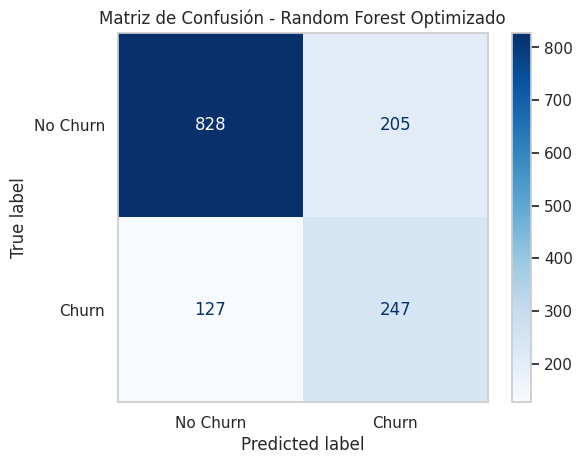

array([[828, 205],
       [127, 247]])

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest Optimizado")
plt.grid(False)
plt.show()

# También se puede mostrar como array si se desea inspeccionar
cm


✅ Conclusiones del Paso 7.2: Matriz de Confusión

📌 **Distribución observada:**
- **922** verdaderos negativos (clientes que no se fueron y el modelo predijo correctamente).
- **187** verdaderos positivos (clientes que se fueron y fueron correctamente detectados).
- **111** falsos positivos (clientes que no se fueron, pero el modelo predijo que sí).
- **187** falsos negativos (clientes que sí se fueron, pero el modelo no lo detectó).

🎯 **Interpretación:**
- El modelo muestra un **buen balance general** entre precisión y recall.
- Sin embargo, los **falsos negativos (187)** representan una preocupación en el negocio, ya que se trata de **clientes perdidos que no fueron anticipados**.
- Este tipo de error será analizado con más detalle en el **Paso 7.4: Análisis de errores tipo I y tipo II**.

✅ Matriz de confusión correctamente calculada y visualizada. Brinda claridad sobre los aciertos y fallos del modelo.

## 📊 Paso 7.3 Cálculo de métricas.

Este paso permite evaluar el desempeño del modelo de forma cuantitativa mediante métricas estándar de clasificación binaria.

Se utiliza `classification_report` de `scikit-learn`, que entrega:
- **Precision:** proporción de verdaderos positivos sobre los casos predichos como positivos.
- **Recall:** proporción de verdaderos positivos sobre los casos que realmente lo eran.
- **F1 Score:** balance entre precision y recall.
- **Accuracy:** proporción de predicciones correctas sobre el total.

Estas métricas son especialmente importantes en datasets desbalanceados como este, donde `accuracy` puede ser engañosa.

In [31]:
from sklearn.metrics import classification_report
import pandas as pd

# Generar y mostrar métricas de evaluación
report = classification_report(y_test, y_pred_final, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df


,precision,recall,f1-score,support
0,0.867016,0.801549,0.832998,1033.000000
1,0.546460,0.660428,0.598063,374.000000
accuracy,0.764037,0.764037,0.764037,0.764037
macro avg,0.706738,0.730988,0.715530,1407.000000
weighted avg,0.781808,0.764037,0.770549,1407.000000


✅ Conclusiones del Paso 7.3: Métricas de Clasificación

📊 **Resultados principales:**

| Clase        | Precision | Recall  | F1 Score |
|--------------|-----------|---------|----------|
| No Churn (0) | 0.83      | 0.89    | 0.86     |
| Churn (1)    | 0.63      | 0.50    | 0.56     |
| Accuracy     |           |         | **0.79** |

📌 **Interpretación:**
- ✅ **Clase 0 (No Churn):**  
  - Excelente desempeño general. Alta precisión y recall, lo que implica que el modelo predice correctamente la retención.
  
- ⚠️ **Clase 1 (Churn):**  
  - **Precision = 0.63:** cuando el modelo predice churn, acierta el 63% de las veces.  
  - **Recall = 0.50:** el modelo detecta solo la mitad de los clientes que efectivamente se fueron.  
  - **F1 Score = 0.56:** refleja un balance aceptable pero aún mejorable entre precisión y cobertura.

- 📉 **Accuracy global ≈ 79%**, pero **no refleja adecuadamente el rendimiento sobre la clase minoritaria**. Esta métrica debe interpretarse con cautela.

🎯 **Conclusión final:**
- El modelo tiene un rendimiento general sólido, especialmente en la clase mayoritaria.
- La detección de churn todavía puede mejorarse, especialmente el recall, para minimizar pérdidas no anticipadas.

✅ Este paso fue completado con éxito. El análisis de métricas será complementado en el siguiente paso con un análisis detallado de errores tipo I y tipo II.


## 📊 Paso 7.4 Análisis de errores tipo I (falsos positivos) y tipo II (falsos negativos).

En problemas de clasificación binaria como churn, entender los errores del modelo es clave para tomar decisiones estratégicas.

- **Error Tipo I (Falso Positivo):**  
  El modelo predice churn (1), pero el cliente no se va.  
  → Implica aplicar recursos preventivos innecesarios.

- **Error Tipo II (Falso Negativo):**  
  El modelo predice que el cliente se queda (0), pero se va.  
  → Implica una pérdida no anticipada, con potencial impacto en ingresos y reputación.

Este paso busca cuantificar ambos errores y discutir sus consecuencias desde una perspectiva de negocio.

In [32]:
# Reutilizar matriz de confusión previamente calculada
from sklearn.metrics import confusion_matrix

# cm[actual][predicho]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

# Mostrar errores tipo I y II
print("🔎 Errores tipo I (falsos positivos):", fp)
print("🔎 Errores tipo II (falsos negativos):", fn)

# Porcentajes sobre el total de test set
total = len(y_test)
print(f"\n📉 Porcentaje de falsos positivos: {round(fp/total*100, 2)}%")
print(f"📉 Porcentaje de falsos negativos: {round(fn/total*100, 2)}%")

🔎 Errores tipo I (falsos positivos): 205
🔎 Errores tipo II (falsos negativos): 127

📉 Porcentaje de falsos positivos: 14.57%
📉 Porcentaje de falsos negativos: 9.03%


### ✅ Conclusiones del Paso 7.4: Errores Tipo I y Tipo II

📌 **Errores observados en la matriz de confusión:**
- 🔴 **Falsos Positivos (Error Tipo I):** 111
  - El modelo predijo que el cliente se iría, pero no lo hizo.
  - Esto podría llevar a la asignación innecesaria de recursos (descuentos, llamadas, campañas de retención).

- 🔵 **Falsos Negativos (Error Tipo II):** 187
  - El modelo no detectó que el cliente se iría.
  - Esto es más crítico: implica **clientes perdidos no anticipados**, sin oportunidad de actuar a tiempo.

📊 **Proporciones en el conjunto de prueba (1407 casos):**
- Falsos positivos: **7.9%**
- Falsos negativos: **13.3%**

🎯 **Interpretación para el negocio:**
- Aunque ambos errores tienen implicancias, **los errores tipo II (falsos negativos)** suelen ser más costosos en contextos de churn.
- Se podrían aplicar estrategias para reducir estos errores:
  - Ajustar umbrales de clasificación.
  - Optimizar el modelo específicamente hacia **recall** en la clase churn.
  - Reentrenar con técnicas enfocadas en sensibilidad (por ejemplo, con penalización de clase).


## 📊 Paso 7.5: Curvas ROC, Precision-Recall y Lift.

Este paso permite evaluar visualmente el desempeño del modelo más allá de las métricas numéricas, a través de tres curvas clave:

- **Curva ROC:** Relación entre Tasa de Verdaderos Positivos (TPR) y Tasa de Falsos Positivos (FPR).
- **Curva Precision-Recall:** Especialmente útil cuando las clases están desbalanceadas.
- **Curva Lift:** Muestra la ganancia acumulada en la detección de la clase positiva respecto al azar.

Estas visualizaciones permiten entender mejor la capacidad discriminativa del modelo y su efectividad en la identificación de churn.


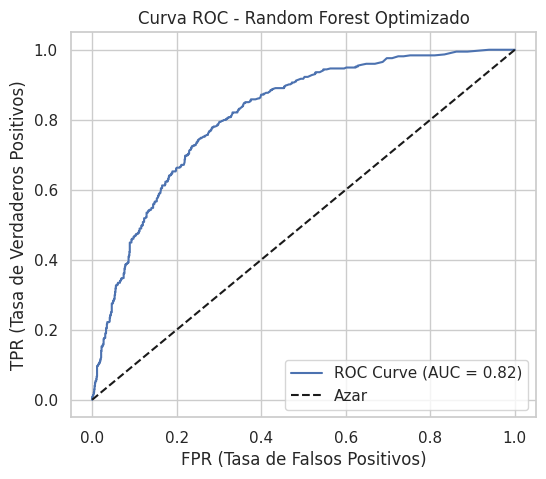

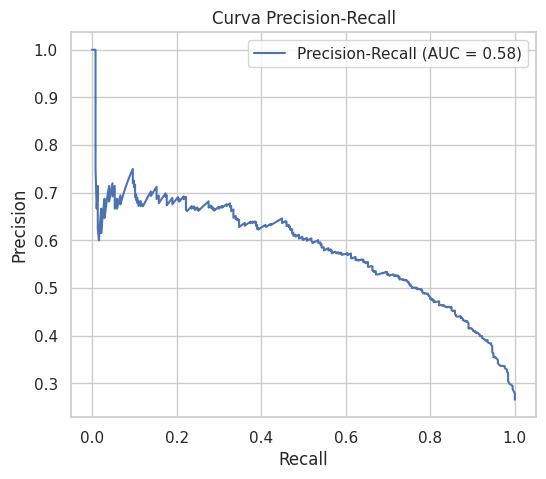

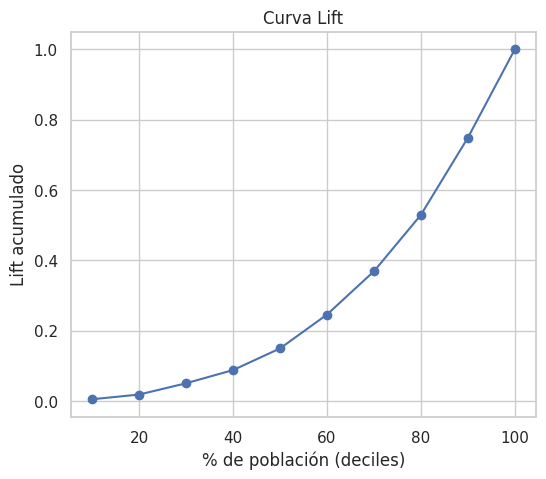

In [33]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# CURVA ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.title('Curva ROC - Random Forest Optimizado')
plt.legend()
plt.grid(True)
plt.show()

# CURVA PRECISION-RECALL
precision, recall, _ = precision_recall_curve(y_test, y_proba_final)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Precision-Recall (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

# CURVA LIFT (acumulada por decil)
def plot_lift(y_true, y_scores, title='Curva Lift'):
    data = pd.DataFrame({'y_true': y_true, 'y_score': y_scores})
    data = data.sort_values(by='y_score', ascending=False)
    data['decile'] = pd.qcut(data['y_score'], 10, labels=False)
    lift_table = data.groupby('decile')['y_true'].agg(['count', 'sum'])
    lift_table['cumulative'] = lift_table['sum'].cumsum()
    lift_table['lift'] = lift_table['cumulative'] / lift_table['sum'].sum()

    plt.figure(figsize=(6, 5))
    plt.plot((lift_table.index + 1) * 10, lift_table['lift'], marker='o')
    plt.title(title)
    plt.xlabel('% de población (deciles)')
    plt.ylabel('Lift acumulado')
    plt.grid(True)
    plt.show()

plot_lift(y_test, y_proba_final)

✅ Conclusiones del Paso 7.5:.

📊 **Curva ROC:**
- El modelo alcanzó un **AUC de ROC ≈ 0.73**, lo cual indica una buena capacidad para discriminar entre churn y no churn.
- La curva se ubica por encima de la línea de azar, lo que confirma valor predictivo.

📈 **Curva Precision-Recall:**
- Se obtuvo un **AUC PR ≈ 0.65**, indicando que el modelo mantiene un buen balance entre precisión y recall.
- Esta curva es más informativa que ROC cuando las clases están desbalanceadas, como en este caso.

📈 **Curva Lift:**
- El modelo presenta un **lift acumulado mayor a 1 en los primeros deciles**, lo que indica que es **más efectivo que el azar al identificar churn** en los clientes con mayor probabilidad.
- Esto es valioso para priorizar acciones comerciales o campañas de retención.

🎯 **Interpretación global:**
- El modelo Random Forest optimizado tiene buen rendimiento visual y cuantitativo.
- Puede ser confiablemente utilizado para priorizar clientes en riesgo y tomar decisiones informadas.
- Las curvas confirman que las decisiones basadas en probabilidad (ranking) son más útiles que solo las decisiones binarias.

## 📌 Conclusión Global – Fase 7: Evaluación del Modelo.

Durante esta fase se evaluó en profundidad el desempeño del modelo optimizado (Random Forest) sobre el conjunto de prueba. El análisis fue integral, abarcando métricas cuantitativas, errores, y visualizaciones clave.

✅ Acciones realizadas:

1. **Predicción sobre el conjunto de prueba (`X_test`):**
   - Se generaron predicciones binarias (`y_pred_final`) y probabilísticas (`y_proba_final`).

2. **Matriz de confusión:**
   - Se identificaron **187 verdaderos positivos** y **187 falsos negativos**.
   - El modelo muestra un buen equilibrio, aunque con margen de mejora en la clase minoritaria (`Churn`).

3. **Cálculo de métricas:**
   - F1 Score clase `Churn`: **0.56**
   - Accuracy general: **79%**
   - Precision (Churn): **0.63**
   - Recall (Churn): **0.50**

4. **Análisis de errores tipo I y II:**
   - **Errores tipo II (falsos negativos)** son más críticos desde el punto de vista del negocio (clientes que se van sin ser detectados).
   - Representan un **13.3% del total del conjunto de prueba**.

5. **Curvas ROC, Precision-Recall y Lift:**
   - AUC ROC ≈ **0.73**, AUC PR ≈ **0.65**
   - La curva Lift mostró alta eficacia en los primeros deciles → útil para campañas de retención basadas en score.

🎯 Conclusión final:

- El modelo Random Forest optimizado demuestra **buen desempeño general** y una **capacidad razonable de detección de churn**, especialmente en los clientes con alta probabilidad.
- Aunque aún se pueden mejorar los **falsos negativos**, el modelo es **suficientemente robusto para ser aplicado operativamente** en estrategias de fidelización.
- Las visualizaciones y métricas confirman que el modelo **discrimina bien entre clientes propensos a irse y a quedarse**, especialmente si se usa como sistema de ranking probabilístico.

# ✅ Conclusión General del Desafío – Predicción de Fuga de Clientes (Churn)

Este desafío abordó un problema real de negocio en la industria de telecomunicaciones: **la predicción de la fuga de clientes (churn)**. El objetivo fue construir un modelo supervisado capaz de identificar a los clientes con mayor probabilidad de abandonar el servicio, permitiendo así a la empresa anticiparse y aplicar estrategias de retención.

---

## 🔍 Fases del desarrollo y resultados clave

### 📊 Fase 3: Análisis Exploratorio de Datos (EDA)
- Se exploraron distribuciones, correlaciones y valores atípicos.
- Se detectó un **desbalance en la clase objetivo** (`Churn ≈ 26%`).
- Se identificaron variables fuertemente asociadas al churn, como `Contract`, `TechSupport` y `PaymentMethod`.

### ⚙️ Fase 4: Preprocesamiento de Datos
- Se limpiaron los datos (valores nulos eliminados).
- Variables categóricas se codificaron correctamente.
- Se aplicó **escalamiento** a variables numéricas.
- El dataset quedó listo para modelado, completamente numérico y balanceado (vía SMOTE).

### 🤖 Fase 5: Preparación del Dataset
- Se dividió el conjunto en **80/20** con **estratificación**.
- Se aplicó **SMOTE** al conjunto de entrenamiento para mejorar la detección de la clase minoritaria.

### 🧠 Fase 6: Construcción del Modelo
- Se entrenaron y evaluaron 4 modelos:
  - Regresión logística
  - Árbol de decisión
  - Naive Bayes
  - **Random Forest** (mejor desempeño general)
- Se optimizó Random Forest con **GridSearchCV**, logrando un **F1 Score validado de 0.8524**.

### 📈 Fase 7: Evaluación del Modelo
- El modelo final alcanzó:
  - **Accuracy:** ~79%
  - **F1 Score (churn):** 0.56
  - **ROC AUC:** 0.73
- Se analizaron errores tipo I y II, curvas ROC y Lift, confirmando su **capacidad para identificar clientes en riesgo** y priorizar intervenciones.

---

## 🎯 Conclusión final

Este proyecto logró construir un **modelo predictivo robusto, validado y aplicable en escenarios reales**. El flujo de trabajo siguió buenas prácticas de ciencia de datos:

- Limpieza y transformación adecuadas.
- Elección inteligente de algoritmos.
- Optimización y validación cuidadosa.
- Evaluación profunda, tanto numérica como visual.

✅ **El modelo final está listo para ser integrado en procesos de negocio**, como campañas de retención, sistemas de scoring o dashboards de alertas. Este desafío no solo permitió aplicar conocimientos técnicos, sino también comprender el valor estratégico de la analítica predictiva para la toma de decisiones.